### Motor imagery decoding from EEG data using the Common Spatial Pattern (CSP)

Decoding of motor imagery applied to EEG data decomposed using CSP. A classifier is then applied to features extracted on CSP-filtered signals.

In [1]:
tmin, tmax = -1.0, 4.0
subjects = 1
runs = [6, 10, 14]  # motor imagery: hand vs feet

In [7]:
from mne.datasets import eegbci

raw_fnames = eegbci.load_data(subjects, runs, path="./data", update_path=True)

In [9]:
from mne.io import concatenate_raws, read_raw_edf

raw = concatenate_raws([read_raw_edf(f, preload=True) for f in raw_fnames])
raw

Extracting EDF parameters from data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>

In [10]:
eegbci.standardize(raw)
raw

<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>

In [11]:
from mne.channels import make_standard_montage

montage = make_standard_montage("standard_1005")
raw.set_montage(montage)
raw.annotations.rename(dict(T1="hands", T2="feet"))  # as documented on PhysioNet
raw.set_eeg_reference(projection=True)

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

In [12]:
# Apply band-pass filter
raw.filter(7.0, 30.0, fir_design="firwin", skip_by_annotation="edge")
raw

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

In [14]:
from mne import Epochs, pick_types

picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")

# Read epochs (train will be done only between 1 and 2s)
# Testing will be done with a running classifier
epochs = Epochs(
    raw,
    event_id=["hands", "feet"],
    tmin=tmin,
    tmax=tmax,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True,
)
epochs_train = epochs.copy().crop(tmin=1.0, tmax=2.0)
labels = epochs.events[:, -1] - 2


Used Annotations descriptions: [np.str_('T0'), np.str_('feet'), np.str_('hands')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
45 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 45 events and 801 original time points ...
0 bad epochs dropped


Computing rank from data with rank=None
    Using tolerance 7.2e-05 (2.2e-16 eps * 64 dim * 5e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 6.9e-05 (2.2e-16 eps * 64 dim * 4.9e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 7.2e

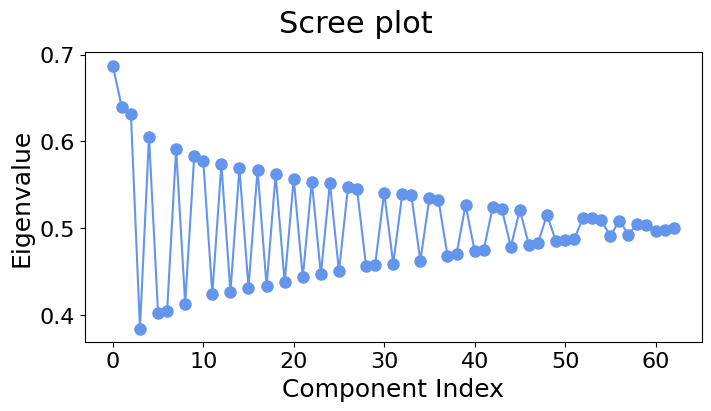

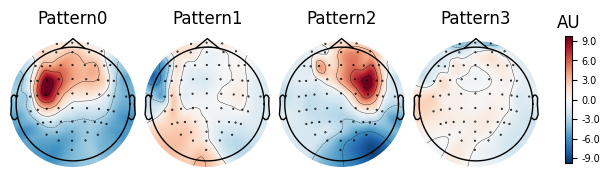

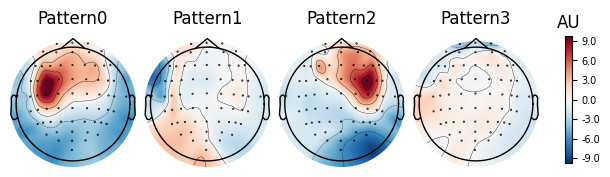

In [15]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from mne.decoding import CSP, get_spatial_filter_from_estimator

# Define a monte-carlo cross-validation generator (reduce variance):
scores = []
epochs_data = epochs.get_data(copy=False)
epochs_data_train = epochs_train.get_data(copy=False)
cv = ShuffleSplit(10, test_size=0.2, random_state=42)
cv_split = cv.split(epochs_data_train)

# Assemble a classifier
lda = LinearDiscriminantAnalysis()
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Use scikit-learn Pipeline with cross_val_score function
clf = Pipeline([("CSP", csp), ("LDA", lda)])
scores = cross_val_score(clf, epochs_data_train, labels, cv=cv, n_jobs=None)

# Printing the results
class_balance = np.mean(labels == labels[0])
class_balance = max(class_balance, 1.0 - class_balance)
print(f"Classification accuracy: {np.mean(scores)} / Chance level: {class_balance}")

# plot eigenvalues and patterns estimated on full data for visualization
csp.fit_transform(epochs_data, labels)
spf = get_spatial_filter_from_estimator(csp, info=epochs.info)
spf.plot_scree()
spf.plot_patterns(components=np.arange(4))


Computing rank from data with rank=None
    Using tolerance 7.2e-05 (2.2e-16 eps * 64 dim * 5e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 6.9e-05 (2.2e-16 eps * 64 dim * 4.9e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 7.2e

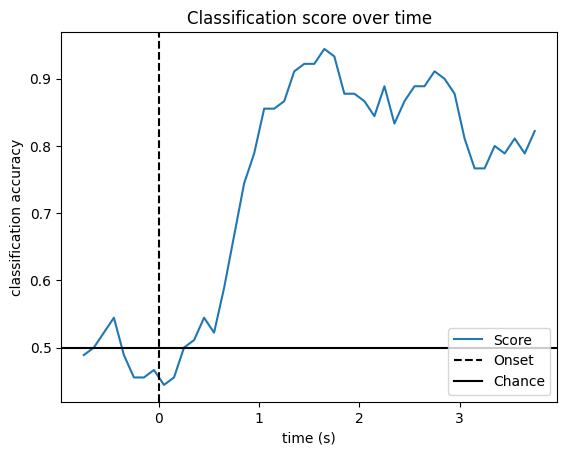

In [16]:
import matplotlib.pyplot as plt

sfreq = raw.info["sfreq"]
w_length = int(sfreq * 0.5)  # running classifier: window length
w_step = int(sfreq * 0.1)  # running classifier: window step size
w_start = np.arange(0, epochs_data.shape[2] - w_length, w_step)

scores_windows = []

for train_idx, test_idx in cv_split:
    y_train, y_test = labels[train_idx], labels[test_idx]

    X_train = csp.fit_transform(epochs_data_train[train_idx], y_train)
    X_test = csp.transform(epochs_data_train[test_idx])

    # fit classifier
    lda.fit(X_train, y_train)

    # running classifier: test classifier on sliding window
    score_this_window = []
    for n in w_start:
        X_test = csp.transform(epochs_data[test_idx][:, :, n : (n + w_length)])
        score_this_window.append(lda.score(X_test, y_test))
    scores_windows.append(score_this_window)

# Plot scores over time
w_times = (w_start + w_length / 2.0) / sfreq + epochs.tmin

plt.figure()
plt.plot(w_times, np.mean(scores_windows, 0), label="Score")
plt.axvline(0, linestyle="--", color="k", label="Onset")
plt.axhline(0.5, linestyle="-", color="k", label="Chance")
plt.xlabel("time (s)")
plt.ylabel("classification accuracy")
plt.title("Classification score over time")
plt.legend(loc="lower right")
plt.show()
